In [7]:
import util
import os
import pickle
import glob

import csv
import copy

import numpy as np
import open3d as o3d
import nibabel as nib
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline


def read_sub(file_path):
    data = {}
    with open(file_path, mode='r') as file:
        csv_reader = csv.reader(file)
        for index, row in enumerate(csv_reader):
            if index==0: continue
            else:
                id= row[0]
                data[row[0]]=row[1:6]
    return data

def read_csv_to_dict(file_path):
    data = {}
    with open(file_path, mode='r') as file:
        csv_reader = csv.reader(file)
        for row in csv_reader:
            if len(row) == 2:  # Ensure there are exactly 2 elements in the row
                key, value = row
                data[key] = int(value)  # Convert the value to integer
    return data

import numpy as np
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import csv

def csv_to_dict(filename):
    result = {}
    with open(filename, newline='', encoding='utf-8') as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:  # skip empty rows
                continue
            key = row[0]
            values = row[1:]
            result[key] = values
    return result



# Read subject availability & Print them
common_sub_csv =  rf"sub.csv"
common_dict = read_sub(common_sub_csv)
print(len(common_dict), common_dict)

# Read ICV dataset & Print the resulting dictionary
csv_file_path = r'ICV_scan1_1_5T.csv'
data_dict = read_csv_to_dict(csv_file_path)


print("Data Dictionary:", data_dict)
total = sum(data_dict.values())
count = len(data_dict)
etiv_mean = total/count
print("Total:", total)
print("Count:", count)
print("Average:", total / count)

# Read longi-factors data
csv_dict = csv_to_dict('w2tow5_LBC1936_hipposhape_longitudinal_MVH.csv')
print(csv_dict)


def glm_vertexwise_longi_analysis(g1, deform_mat, age11IQ, g2):
    """
    Exact replication of MATLAB:
    g2 ~ g1 + deformation_v + age11IQ   for each vertex v
    
    Returns beta, p, se for the deformation term (like MATLAB stats1.p(3))
    """
    g1 = np.asarray(g1).ravel()
    age11IQ = np.asarray(age11IQ).ravel()
    g2 = np.asarray(g2).ravel()
    deform_mat = np.asarray(deform_mat)
    
    n_subjects, n_vertices = deform_mat.shape
    
    beta = np.zeros(n_vertices)
    pval = np.zeros(n_vertices)
    se = np.zeros(n_vertices)
    dev = np.zeros(n_vertices)
    for v in range(n_vertices):
        deform_v = deform_mat[:, v]
        
        # Design matrix: exactly as in MATLAB
        # X = np.column_stack([g1, deform_v, age11IQ])
        X = np.column_stack([g1, deform_v, age11IQ])
        X = sm.add_constant(X)  # adds intercept first
        
        # OLS = identical to MATLAB glmfit with normal errors
        model = sm.GLM(g2, X, family=sm.families.Gaussian()).fit()
        
        beta[v] = model.params[2]      # deformation coefficient
        pval[v] = model.pvalues[2]     # p-value for deformation
        # print(model.pvalues)
        se[v] = model.bse[2]           # standard error
        dev[v]  = model.deviance 
    return beta, pval, se, dev


def glm_vertexwise_cross_analysis(g1, deform_mat):
    """
    Exact replication of MATLAB:
    g2 ~ g1 + deformation_v + age11IQ   for each vertex v
    
    Returns beta, p, se for the deformation term (like MATLAB stats1.p(3))
    """
    g1 = np.asarray(g1).ravel()
    deform_mat = np.asarray(deform_mat)
    
    n_subjects, n_vertices = deform_mat.shape
    
    beta = np.zeros(n_vertices)
    pval = np.zeros(n_vertices)
    se = np.zeros(n_vertices)
    dev = np.zeros(n_vertices)
    for v in range(n_vertices):
        deform_v = deform_mat[:, v]
        
        # Design matrix: exactly as in MATLAB
        # X = np.column_stack([g1, deform_v, age11IQ])
        X = np.column_stack([deform_v])
        X = sm.add_constant(X)  # adds intercept first
        
        # OLS = identical to MATLAB glmfit with normal errors
        model = sm.GLM(g1, X, family=sm.families.Gaussian()).fit()
        
        beta[v] = model.params[1]      # deformation coefficient
        pval[v] = model.pvalues[1]     # p-value for deformation
        # print(model.pvalues)
        se[v] = model.bse[1]           # standard error
        dev[v]  = model.deviance 
    return beta, pval, se, dev


693 {'LBC360002': ['1', '1', '1', '1', '1'], 'LBC360003': ['1', '1', '0', '0', '0'], 'LBC360004': ['1', '1', '1', '1', '1'], 'LBC360006': ['1', '1', '1', '1', '1'], 'LBC360007': ['1', '1', '1', '1', '1'], 'LBC360008': ['1', '1', '1', '1', '1'], 'LBC360009': ['1', '1', '1', '1', '0'], 'LBC360013': ['1', '0', '0', '0', '0'], 'LBC360015': ['1', '1', '1', '1', '1'], 'LBC360017': ['1', '1', '1', '1', '0'], 'LBC360020': ['1', '1', '0', '1', '1'], 'LBC360021': ['1', '1', '1', '0', '0'], 'LBC360022': ['1', '1', '1', '1', '0'], 'LBC360023': ['1', '0', '1', '1', '1'], 'LBC360025': ['0', '0', '1', '1', '1'], 'LBC360026': ['1', '1', '1', '1', '0'], 'LBC360029': ['1', '0', '0', '0', '0'], 'LBC360030': ['1', '1', '1', '1', '1'], 'LBC360031': ['1', '1', '1', '1', '1'], 'LBC360032': ['1', '1', '0', '0', '0'], 'LBC360034': ['1', '1', '1', '1', '0'], 'LBC360036': ['1', '1', '0', '0', '0'], 'LBC360038': ['1', '0', '0', '0', '0'], 'LBC360040': ['1', '0', '1', '1', '1'], 'LBC360041': ['1', '1', '0', '0', '

In [28]:
import copy
import glob
import os

import numpy as np
import open3d as o3d
import pandas as pd

# ========================= CONFIG =========================
labels = [58]

# Time point pairs for longitudinal analysis
past_now_pairs = [(0,1), (1,2), (2,3), (0,2), (1,3), (0,3)]

optim_dir = r'C:\Users\fabi\Desktop\edinburgh-optimed-20251220T054003Z-3-002\edinburgh-optimed'

viridis = plt.cm.hot
# =========================================================


def compute_signed_displacement(past, now, template_mesh):
    """Compute signed displacement between past and current point clouds.
    
    The sign is determined by the surface normal at the 'now' position.
    """
    delta = np.asarray(now) - np.asarray(past)
    norm = np.linalg.norm(delta, axis=1)

    # Create a temporary copy of the template mesh for normal calculation
    temp_mesh = copy.deepcopy(template_mesh)
    
    # Update vertices to current position and compute normals
    temp_mesh.vertices = o3d.utility.Vector3dVector(np.asarray(now))
    temp_mesh.compute_vertex_normals()
    normals = np.asarray(temp_mesh.vertex_normals)

    # Positive if moving outward (along normal), negative if inward
    dot_products = np.einsum('ij,ij->i', normals, delta)
    signs = np.where(dot_products >= 0, 1, -1)
    
    return signs * norm


for label in labels:
    print(f"\n=== Processing Label {label} ===")
    
    os.makedirs(f'pvalues/{label}', exist_ok=True)
    os.makedirs(f'deformities/{label}', exist_ok=True)

    # Load template mesh once per label
    template_mesh = o3d.io.read_triangle_mesh(f'../temp_meshes/{label}_temp.obj')
    num_vert = len(template_mesh.vertices)

    for icv_norm in [False, True]:
        icv_flag = '_icv_norm' if icv_norm else ''
        icvnorm_suffix = '_ICVnorm' if icv_norm else ''
        
        for t1, t2 in past_now_pairs:
            print(f"  → Time pair: {t1+1} → {t2+1}  (ICV norm: {icv_norm})")
            
            analysis_d = {}
            colors = np.zeros((693, num_vert, 3))
            count = 0

            txt_path = f'deformities/{label}/LocalDeformity_longi{icv_flag}_{t1+1}{t2+1}_{label}.txt'
            
            with open(txt_path, 'a') as f:
                for key in common_dict.keys():
                    if (common_dict[key][t1] != '1' or 
                        common_dict[key][t2] != '1' or 
                        key[3:] not in data_dict):
                        continue

                    try:
                        # Load point clouds
                        past_file = glob.glob(f"{optim_dir}/{label}/scan{t1+1}/{key}/5000*.npy")[0]
                        now_file  = glob.glob(f"{optim_dir}/{label}/scan{t2+1}/{key}/5000*.npy")[0]
                        
                        past = np.load(past_file)[0]
                        now  = np.load(now_file)[0]

                        # Compute signed displacement
                        disp = compute_signed_displacement(past, now, template_mesh)

                        # ICV normalization
                        if icv_norm:
                            etiv = int(data_dict[key[3:]])
                            disp = disp / (etiv / etiv_mean)

                        # Store color for mean visualization
                        color = np.asarray(viridis(disp + 1.5))
                        colors[count] = color[:, :3]
                        count += 1

                        # Write to deformity txt file
                        sub_id = key[3:] + "_L"
                        f.write(f"{sub_id} ")
                        np.savetxt(f, disp, fmt='%.5f', delimiter=' ', newline=' ')
                        f.write(" ***\n")

                        analysis_d[key[3:]] = disp

                    except Exception as e:
                        print(f"    [Skipped] key={key} | error: {e}")
                        continue

            # Create mean deformity mesh (optional)
            if count > 0:
                mean_color = colors[:count].mean(axis=0)
                deform_mesh = copy.deepcopy(template_mesh)
                deform_mesh.vertex_colors = o3d.utility.Vector3dVector(mean_color)

            # ====================== Statistical Analysis ======================
            iq_vec, g1_list, g2_list, X = [], [], [], []

            for key in analysis_d:
                disp = analysis_d[key]
                csv_key = 'LBC' + key
                
                if (csv_dict.get(csv_key) and 
                    csv_dict[csv_key][4] and 
                    csv_dict[csv_key][t2] and 
                    csv_dict[csv_key][t1]):
                    
                    iq_vec.append(float(csv_dict[csv_key][4]))
                    g1_list.append(float(csv_dict[csv_key][t1]))
                    g2_list.append(float(csv_dict[csv_key][t2]))
                    X.append(disp)

            if len(X) == 0:
                print(f"  No valid subjects for statistical analysis. Skipping.")
                continue

            X = np.asarray(X)
            iq_vec = np.asarray(iq_vec)
            g1 = np.asarray(g1_list)
            g2 = np.asarray(g2_list)

            # Run vertex-wise GLM / ANCOVA
            beta, p, se, dev = glm_vertexwise_longi_analysis(g1, X, iq_vec, g2)

            # Save results
            N = len(beta)
            df = pd.DataFrame({
                "Vertex_no": np.arange(1, N + 1, dtype=int),
                "beta_model1": beta,
                "p_model1": p,
                "dev_model1": dev,
                "SE_model1": se
            })

            csv_path = f"pvalues/{label}/ANCOVA_{t1+1}{t2+1}_{label}{icvnorm_suffix}_results.csv"
            df.to_csv(csv_path, index=False)
            print(f"  Saved: {csv_path}")

print("\nAll processing completed.")


=== Processing Label 58 ===
  → Time pair: 1 → 2  (ICV norm: False)
  Saved: pvalues/58/ANCOVA_12_58_results.csv
  → Time pair: 2 → 3  (ICV norm: False)
  Saved: pvalues/58/ANCOVA_23_58_results.csv
  → Time pair: 3 → 4  (ICV norm: False)
  Saved: pvalues/58/ANCOVA_34_58_results.csv
  → Time pair: 1 → 3  (ICV norm: False)
  Saved: pvalues/58/ANCOVA_13_58_results.csv
  → Time pair: 2 → 4  (ICV norm: False)
  Saved: pvalues/58/ANCOVA_24_58_results.csv
  → Time pair: 1 → 4  (ICV norm: False)
  Saved: pvalues/58/ANCOVA_14_58_results.csv
  → Time pair: 1 → 2  (ICV norm: True)
  Saved: pvalues/58/ANCOVA_12_58_ICVnorm_results.csv
  → Time pair: 2 → 3  (ICV norm: True)
  Saved: pvalues/58/ANCOVA_23_58_ICVnorm_results.csv
  → Time pair: 3 → 4  (ICV norm: True)
  Saved: pvalues/58/ANCOVA_34_58_ICVnorm_results.csv
  → Time pair: 1 → 3  (ICV norm: True)
  Saved: pvalues/58/ANCOVA_13_58_ICVnorm_results.csv
  → Time pair: 2 → 4  (ICV norm: True)
  Saved: pvalues/58/ANCOVA_24_58_ICVnorm_results.csv
 

In [27]:
import copy
import glob
import os

import numpy as np
import open3d as o3d
import pandas as pd

# ========================= CONFIG =========================
labels = [58]#10, 11, 12, 13, 17, 18, 26, 28, 49, 50, 51, 52, 53, 54, 58, 60]

# Time points for cross-sectional analysis
time_points = [0, 1, 2, 3]

optim_dir = r'C:\Users\fabi\Desktop\edinburgh-optimed-20251220T054003Z-3-002\edinburgh-optimed'  # Adjust if the relative path changes

# =========================================================


def compute_signed_displacement(past, now, template_mesh):
    """Compute signed displacement from past to current position.
    
    Sign is determined by the surface normal at the 'now' (template) position.
    """
    delta = np.asarray(now) - np.asarray(past)
    norm = np.linalg.norm(delta, axis=1)

    # Use a copy to avoid modifying the original template
    temp_mesh = copy.deepcopy(template_mesh)
    temp_mesh.vertices = o3d.utility.Vector3dVector(np.asarray(now))
    temp_mesh.compute_vertex_normals()
    normals = np.asarray(temp_mesh.vertex_normals)

    dot_products = np.einsum('ij,ij->i', normals, delta)
    signs = np.where(dot_products >= 0, 1, -1)

    return signs * norm


for label in labels:
    print(f"\n=== Processing Label {label} ===")
    
    os.makedirs(f'pvalues/{label}', exist_ok=True)
    os.makedirs(f'deformities/{label}', exist_ok=True)

    # Load template mesh once
    template_mesh = o3d.io.read_triangle_mesh(
        f'../temp_meshes/{label}_temp.obj'
    )
    now = np.asarray(template_mesh.vertices)
    num_vert = len(template_mesh.vertices)

    for icv_norm in [False, True]:
        icv_flag = '_icv_norm' if icv_norm else ''
        icvnorm_suffix = '_ICVnorm' if icv_norm else ''

        for t in time_points:
            print(f"  → Time point: {t+1}  (ICV norm: {icv_norm})")
            
            analysis_d = {}
            colors = np.zeros((693, num_vert, 3))
            count = 0

            txt_path = f'deformities/{label}/LocalDeformity_cross{icv_flag}_{t+1}_{label}.txt'

            with open(txt_path, 'a') as f:
                for key in common_dict.keys():
                    if common_dict[key][t] != '1' or key[3:] not in data_dict:
                        continue

                    try:
                        # Load point cloud for this time point
                        file_list = glob.glob(f"{optim_dir}/{label}/scan{t+1}/{key}/5000*.npy")
                        if not file_list:
                            continue
                        
                        past = np.load(file_list[0])[0]

                        # Compute signed displacement
                        disp = compute_signed_displacement(past, now, template_mesh)

                        # Apply ICV normalization if requested
                        if icv_norm:
                            etiv = int(data_dict[key[3:]])
                            disp = disp / (etiv / etiv_mean)

                        # Store color for mean deformity mesh
                        color = np.asarray(viridis(disp + 1.5))
                        colors[count] = color[:, :3]
                        count += 1

                        # Write to txt file
                        sub_id = key[3:] + "_L"
                        f.write(f"{sub_id} ")
                        np.savetxt(f, disp, fmt='%.5f', delimiter=' ', newline=' ')
                        f.write(" ***\n")

                        analysis_d[key[3:]] = disp

                    except Exception as e:
                        print(f"    [Skipped] key={key} | error: {e}")
                        continue

            # ====================== Statistical Analysis ======================
            g1_list = []
            X = []

            for key in analysis_d:
                disp = analysis_d[key]
                csv_key = 'LBC' + key

                if csv_dict.get(csv_key) and csv_dict[csv_key][t] != '':
                    g1_list.append(float(csv_dict[csv_key][t]))
                    X.append(disp)

            if len(X) == 0:
                print(f"  No valid subjects for analysis at time {t+1}. Skipping.")
                continue

            X = np.asarray(X)
            g1 = np.asarray(g1_list)

            # Run cross-sectional GLM analysis
            beta, p, se, dev = glm_vertexwise_cross_analysis(g1, X)

            # Save results to CSV
            N = len(beta)
            df = pd.DataFrame({
                "Vertex_no": np.arange(1, N + 1, dtype=int),
                "beta_model1": beta,
                "p_model1": p,
                "dev_model1": dev,
                "SE_model1": se
            })

            csv_path = f"pvalues/{label}/cross_ANCOVA_{t+1}_{label}{icvnorm_suffix}_results.csv"
            df.to_csv(csv_path, index=False)
            print(f"  Saved: {csv_path}")

            # Optional: Create p-value colored mesh for visualization
            p_clipped = p.copy()
            p_clipped[p_clipped > 0.1] = 0.1
            pval_color = plt.cm.viridis(p_clipped * 20)

            pval_mesh = copy.deepcopy(template_mesh)
            pval_mesh.vertex_colors = o3d.utility.Vector3dVector(pval_color[:, :3])

            # You can collect meshes here if needed for visualization
            # obj.append(pval_mesh)

print("\nAll cross-sectional processing completed.")


=== Processing Label 58 ===
  → Time point: 1  (ICV norm: False)
  Saved: pvalues/58/cross_ANCOVA_1_58_results.csv
  → Time point: 2  (ICV norm: False)
  Saved: pvalues/58/cross_ANCOVA_2_58_results.csv
  → Time point: 3  (ICV norm: False)
  Saved: pvalues/58/cross_ANCOVA_3_58_results.csv
  → Time point: 4  (ICV norm: False)
  Saved: pvalues/58/cross_ANCOVA_4_58_results.csv
  → Time point: 1  (ICV norm: True)
  Saved: pvalues/58/cross_ANCOVA_1_58_ICVnorm_results.csv
  → Time point: 2  (ICV norm: True)
  Saved: pvalues/58/cross_ANCOVA_2_58_ICVnorm_results.csv
  → Time point: 3  (ICV norm: True)
  Saved: pvalues/58/cross_ANCOVA_3_58_ICVnorm_results.csv
  → Time point: 4  (ICV norm: True)
  Saved: pvalues/58/cross_ANCOVA_4_58_ICVnorm_results.csv

All cross-sectional processing completed.



=== Processing Label 58 ===


c:\Users\fabi\.conda\envs\o3d\lib\site-packages\pyvista\jupyter\notebook.py:34: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


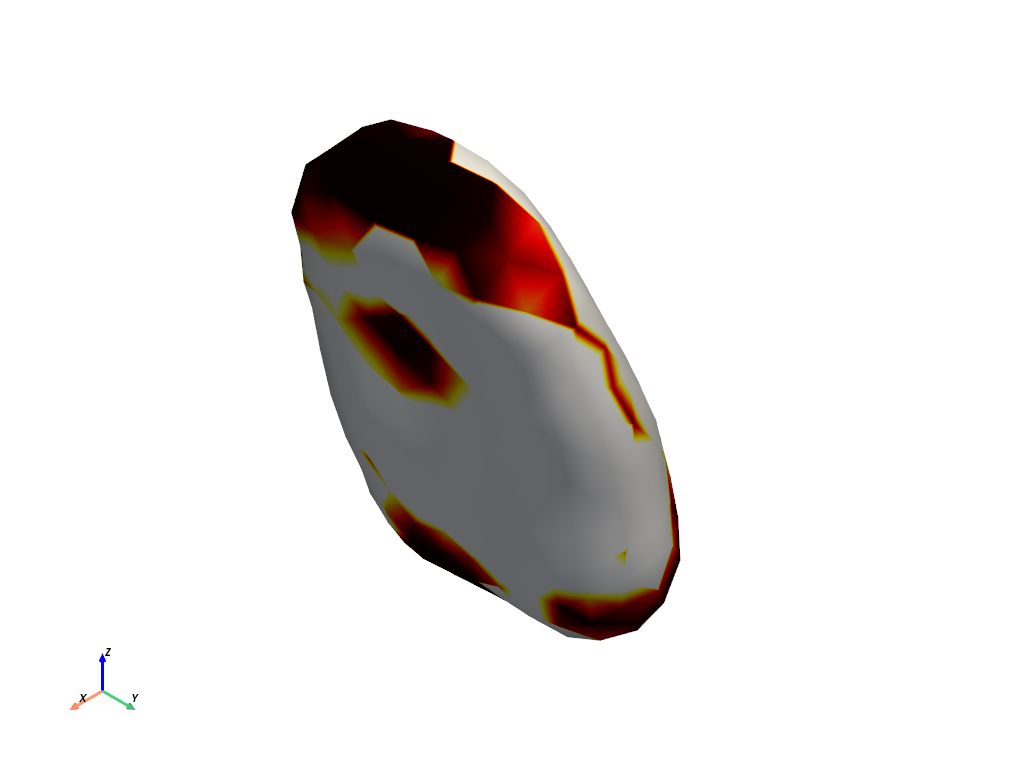

c:\Users\fabi\.conda\envs\o3d\lib\site-packages\pyvista\jupyter\notebook.py:34: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


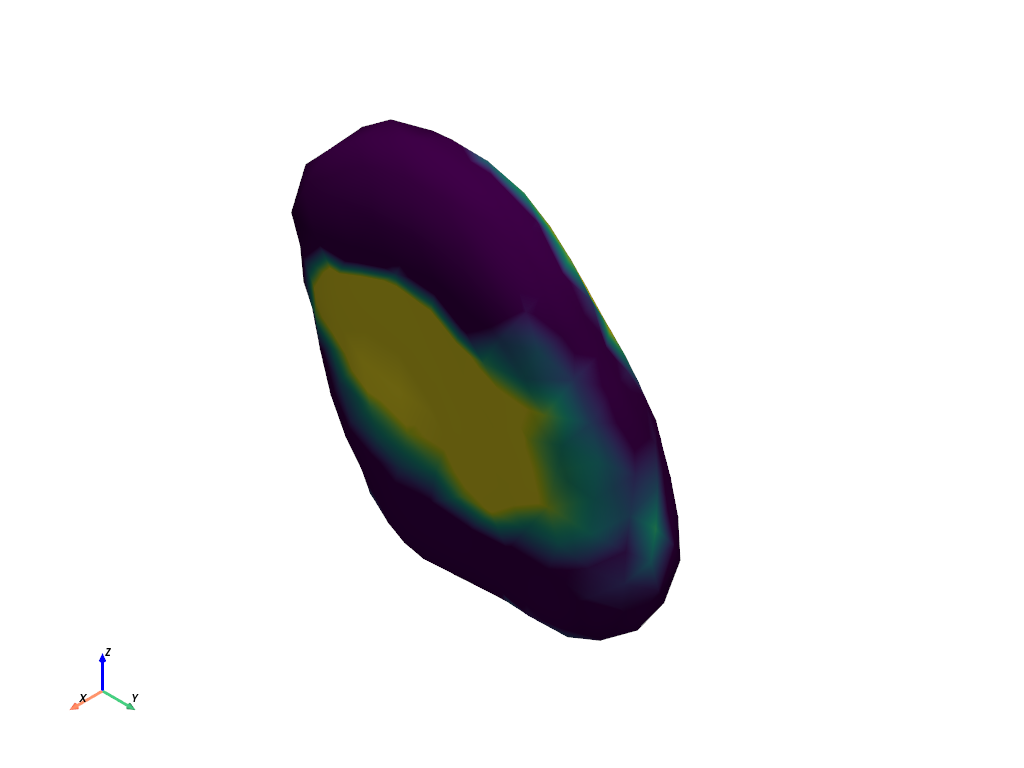

c:\Users\fabi\.conda\envs\o3d\lib\site-packages\pyvista\jupyter\notebook.py:34: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


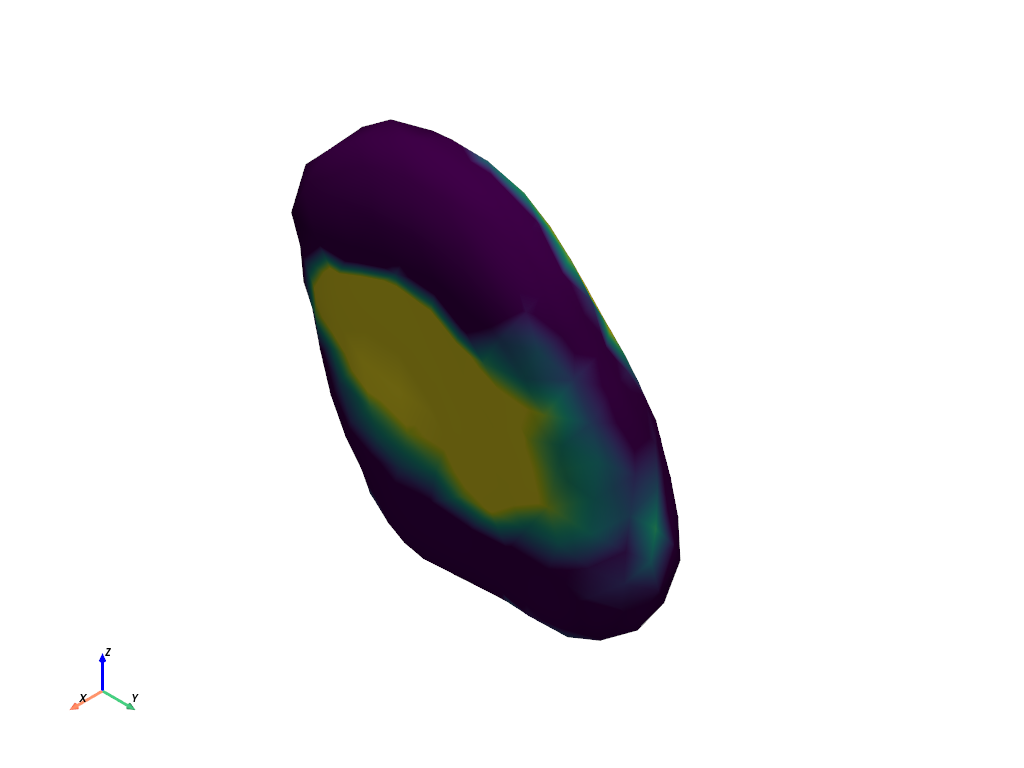

Label 58 visualization saved successfully.


In [24]:
import copy
import os

import numpy as np
import open3d as o3d
import pandas as pd
import pyvista as pv

# ========================= CONFIG =========================
labels = [58]

# =========================================================

def rotate_about_axis(mesh, axis, angle, center=None):
    mesh2 = copy.deepcopy(mesh)
    axis = np.asarray(axis, dtype=float) / (np.linalg.norm(axis) + 1e-12)
    R = o3d.geometry.get_rotation_matrix_from_axis_angle(axis * angle)
    
    if center is None:
        center = mesh2.get_center()
    
    mesh2.rotate(R, center=center)
    return mesh2


for label in labels:
    print(f"\n=== Processing Label {label} ===")
    # Load template mesh & LMM results
    temp_mesh = o3d.io.read_triangle_mesh(f'../temp_meshes/{label}_temp.obj')
    df = pd.read_csv(rf'pvalues\58\cross_ANCOVA_1_58_results.csv')
    
    beta = df["beta_model1"].values
    pval = df["p_model1"].values
    
    # Mesh 준비 및 회전
    mesh_r = copy.deepcopy(temp_mesh)
    
    rotations = [
        (np.pi/2,  0,          0),
        (0,        0,   np.pi/4 * 3),
        (0,       -np.pi/10,   0),
        (np.pi/10, 0,          0)
    ]
    
    for rot in rotations:
        R = temp_mesh.get_rotation_matrix_from_xyz(rot)
        mesh_r.rotate(R, center=(0, 0, 0))

        
    # PyVista 메쉬로 변환
    verts = np.asarray(mesh_r.vertices)
    faces = np.asarray(mesh_r.triangles)
    faces_pv = np.hstack([np.full((len(faces), 1), 3), faces]).astype(np.int64)
    
    mesh_pv = pv.PolyData(verts, faces_pv)
    
    # ====================== Visualization ======================
    common_mesh_args = {
        'smooth_shading': True,
        'show_edges': True,
        'edge_opacity': 0,
        'show_scalar_bar': False,
    }
    
    # ------------------- P-value Plot -------------------
    mesh_pv.point_data["p_value"] = pval
    
    plotter = pv.Plotter(off_screen=True)
    plotter.add_mesh(
        mesh_pv,
        scalars="p_value",
        cmap="hot",
        clim=[0, 0.1],
        **common_mesh_args
    )
    plotter.add_axes(line_width=3, color="black", labels_off=False)
    
    plotter.show(auto_close=False)
    # plotter.screenshot(f'LMM/figures/{label}_pvalue_front.png')
    
    plotter.close()
    
    # ------------------- Beta Plot -------------------
    mesh_pv.point_data["beta"] = beta
    
    plotter = pv.Plotter(off_screen=True)
    plotter.add_mesh(
        mesh_pv,
        scalars="beta",
        cmap="viridis",
        clim=[-0.4, 0.4],
        **common_mesh_args
    )
    plotter.add_axes(line_width=3, color="black", labels_off=False)
    
    plotter.show(auto_close=False)
    # plotter.screenshot(f'LMM/figures/{label}_beta_front.png')
    plotter.close()
    
    # ------------------- Beta Plot -------------------
    mesh_pv.point_data["beta"] = beta
    
    plotter = pv.Plotter(off_screen=True)
    plotter.add_mesh(
        mesh_pv,
        scalars="beta",
        cmap="viridis",
        clim=[-0.4, 0.4],
        **common_mesh_args
    )
    plotter.add_axes(line_width=3, color="black", labels_off=False)
    
    plotter.show(auto_close=False)
    # plotter.screenshot(f'LMM/figures/{label}_beta_front.png')
    plotter.close()
    
    print(f"Label {label} visualization saved successfully.")